# 104 --- Greeks and Volatility Surface

This notebook builds a full volatility surface for SPY across multiple
expirations and strikes, then visualizes the Greeks in 3D and as heatmaps.

1. Fetch multiple expirations
2. For each expiration, compute Greeks across strikes
3. Build the IV surface (strike x expiration x IV)
4. 3D surface plot and heatmap
5. Delta, gamma, theta visualizations
6. Time decay analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime

from thetadatadx import (
    Credentials, Config, ThetaDataDx, to_dataframe,
    all_greeks, implied_volatility,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
creds = Credentials.from_file("creds.txt")
tdx = ThetaDataDx(creds, Config.production())

## 1. Fetch Multiple Expirations

We select 6 expirations spanning from near-term to several months out.

In [3]:
all_exps = tdx.option_list_expirations("SPY")
today = datetime.now()

# Pick expirations at roughly 7, 14, 30, 60, 90, 120 DTE
target_dtes = [7, 14, 30, 60, 90, 120]
selected_exps = []

for target in target_dtes:
    best = None
    best_diff = 999
    for exp_str in all_exps:
        exp_date = datetime.strptime(exp_str.replace("-", ""), "%Y%m%d")
        dte = (exp_date - today).days
        if dte > 0 and abs(dte - target) < best_diff:
            best_diff = abs(dte - target)
            best = exp_str
    if best and best not in selected_exps:
        selected_exps.append(best)

for exp_str in selected_exps:
    exp_date = datetime.strptime(exp_str.replace("-", ""), "%Y%m%d")
    dte = (exp_date - today).days
    print(f"  {exp_str}  ({dte} DTE)")

  2026-04-24  (7 DTE)
  2026-05-01  (14 DTE)
  2026-05-15  (28 DTE)
  2026-06-18  (62 DTE)
  2026-07-17  (91 DTE)
  2026-08-21  (126 DTE)


In [4]:
# Get spot price
spot_snap = tdx.stock_snapshot_ohlc(["SPY"])
spot = spot_snap["close"][0]
print(f"SPY spot: ${spot:.2f}")

# Parameters for Greeks calculation
RISK_FREE = 0.05
DIV_YIELD = 0.013

SPY spot: $701.54


## 2. Compute Greeks Across All Expirations and Strikes

For each expiration, fetch call mid-prices and compute the full
Greeks using the built-in Rust calculator.

In [5]:
surface_data = []

for exp_str in selected_exps:
    exp_date = datetime.strptime(exp_str.replace("-", ""), "%Y%m%d")
    dte = (exp_date - today).days
    tte = dte / 365.0

    # Get strikes within +/- 8% of spot
    strikes_raw = tdx.option_list_strikes("SPY", exp_str)
    strikes_f = [(s, float(s)) for s in strikes_raw]
    strikes_f = [(s, v) for s, v in strikes_f if spot * 0.92 <= v <= spot * 1.08]

    print(f"  {exp_str} ({dte:3d} DTE): {len(strikes_f)} strikes", end="")

    count = 0
    for strike_str, strike_val in strikes_f:
        try:
            call_q = tdx.option_snapshot_quote("SPY", exp_str, strike_str, "C")
            if not call_q:
                continue
            mid = (call_q["bid"][0] + call_q["ask"][0]) / 2
            if mid <= 0.01:
                continue

            g = all_greeks(
                spot=spot, strike=strike_val, rate=RISK_FREE,
                div_yield=DIV_YIELD, tte=tte, option_price=mid, right="C",
            )

            if g["iv_error"] < 0.01:
                surface_data.append({
                    "expiration": exp_str,
                    "dte": dte,
                    "strike": strike_val,
                    "moneyness": strike_val / spot,
                    "mid": mid,
                    "iv": g["iv"],
                    "delta": g["delta"],
                    "gamma": g["gamma"],
                    "theta": g["theta"],
                    "vega": g["vega"],
                    "vanna": g["vanna"],
                    "charm": g["charm"],
                    "vomma": g["vomma"],
                })
                count += 1
        except Exception:
            continue

    print(f" -> {count} valid")

surface = pd.DataFrame(surface_data)
print(f"\nTotal data points: {len(surface)}")

  2026-04-24 (  7 DTE): 87 strikes

 -> 86 valid
  2026-05-01 ( 14 DTE): 78 strikes

 -> 77 valid
  2026-05-15 ( 28 DTE): 78 strikes

 -> 78 valid
  2026-06-18 ( 62 DTE): 22 strikes

 -> 22 valid
  2026-07-17 ( 91 DTE): 22 strikes

 -> 22 valid
  2026-08-21 (126 DTE): 22 strikes

 -> 22 valid

Total data points: 307


## 3. Build the Volatility Surface

In [6]:
# Pivot: rows = strikes (moneyness), columns = DTE, values = IV
# Round moneyness to 0.5% buckets for cleaner grid
surface["moneyness_bucket"] = (surface["moneyness"] * 200).round() / 200

iv_pivot = surface.pivot_table(
    index="moneyness_bucket", columns="dte", values="iv", aggfunc="mean"
)

print(f"Surface grid: {iv_pivot.shape[0]} moneyness levels x {iv_pivot.shape[1]} expirations")
iv_pivot.head()

Surface grid: 29 moneyness levels x 6 expirations


dte,7,14,28,62,91,126
moneyness_bucket,,,,,,
0.920,0.283203,0.257019,0.237000,NaN,NaN,NaN
0.925,0.274740,0.251709,0.233053,0.218948,0.206528,0.208679
0.930,0.265137,0.244171,0.227066,NaN,NaN,NaN
0.935,0.253906,0.237122,0.221771,0.212723,0.196350,0.204376
0.940,0.244446,0.230453,0.215248,0.208344,0.193817,0.200104


## 4. Plot the IV Surface

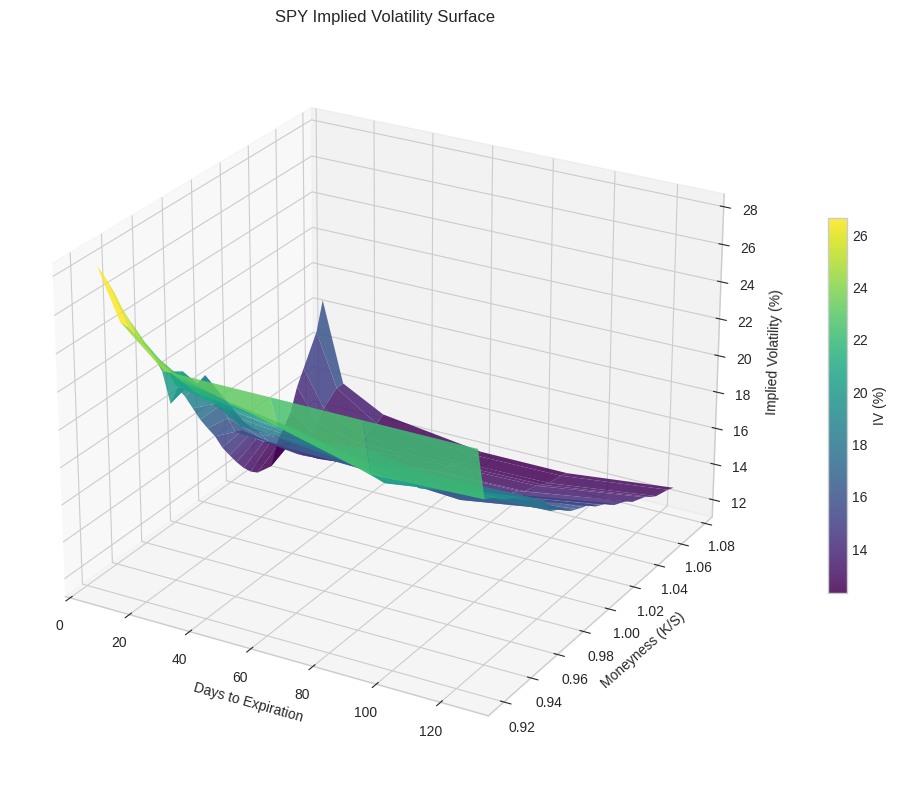

In [7]:
# 3D surface plot
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

X = iv_pivot.columns.values   # DTE
Y = iv_pivot.index.values     # Moneyness
X_grid, Y_grid = np.meshgrid(X, Y)
Z = iv_pivot.values * 100     # IV in %

# Fill NaN with interpolation for smoother surface
Z_filled = pd.DataFrame(Z).interpolate(axis=0).interpolate(axis=1).values

surf = ax.plot_surface(X_grid, Y_grid, Z_filled, cmap=cm.viridis,
                       alpha=0.85, edgecolor="none", antialiased=True)

ax.set_xlabel("Days to Expiration")
ax.set_ylabel("Moneyness (K/S)")
ax.set_zlabel("Implied Volatility (%)")
ax.set_title("SPY Implied Volatility Surface")
ax.view_init(elev=25, azim=-60)

fig.colorbar(surf, ax=ax, shrink=0.5, label="IV (%)")
plt.tight_layout()
plt.show()

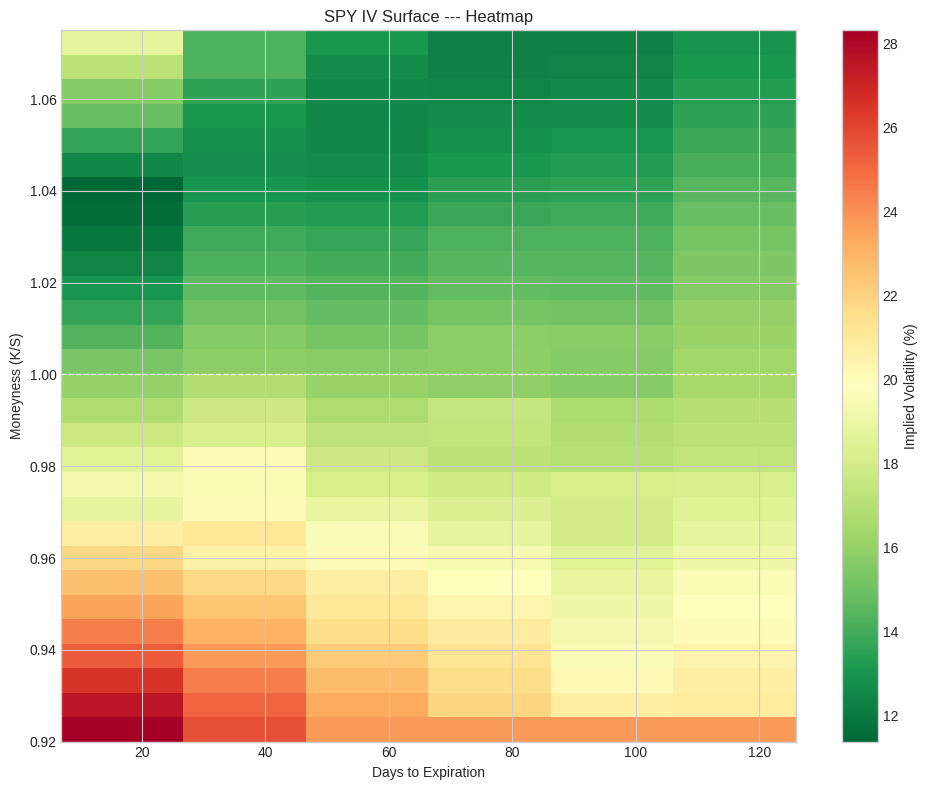

In [8]:
# Heatmap view
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(Z_filled, cmap="RdYlGn_r", aspect="auto",
               extent=[X.min(), X.max(), Y.min(), Y.max()],
               origin="lower")

ax.axhline(y=1.0, color="white", linestyle="--", linewidth=1, alpha=0.8)
ax.set_xlabel("Days to Expiration")
ax.set_ylabel("Moneyness (K/S)")
ax.set_title("SPY IV Surface --- Heatmap")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Implied Volatility (%)")

plt.tight_layout()
plt.show()

## 5. Delta, Gamma, Theta Across the Surface

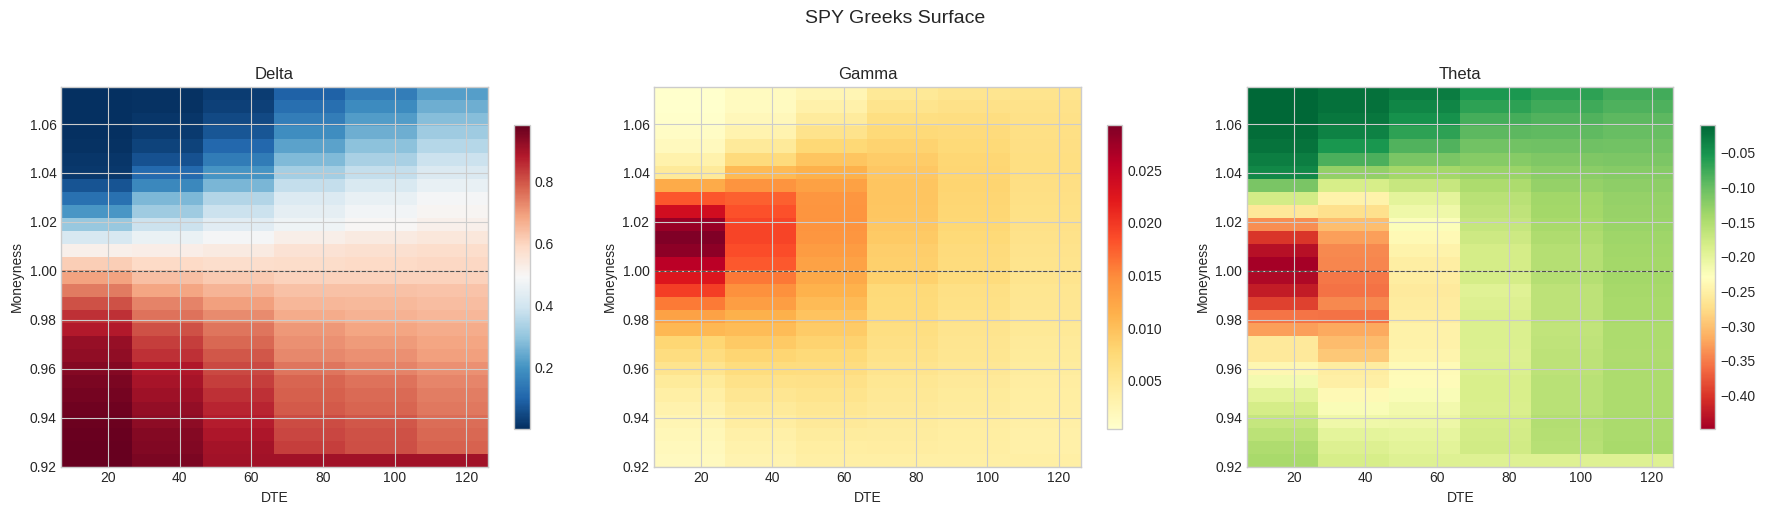

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

greeks_to_plot = [
    ("delta", "Delta", "RdBu_r"),
    ("gamma", "Gamma", "YlOrRd"),
    ("theta", "Theta", "RdYlGn"),
]

for ax, (col, title, cmap) in zip(axes, greeks_to_plot):
    pivot = surface.pivot_table(
        index="moneyness_bucket", columns="dte", values=col, aggfunc="mean"
    )
    Z = pivot.values
    Z_filled = pd.DataFrame(Z).interpolate(axis=0).interpolate(axis=1).values

    im = ax.imshow(
        Z_filled, cmap=cmap, aspect="auto",
        extent=[pivot.columns.min(), pivot.columns.max(),
                pivot.index.min(), pivot.index.max()],
        origin="lower",
    )
    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("DTE")
    ax.set_ylabel("Moneyness")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("SPY Greeks Surface", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

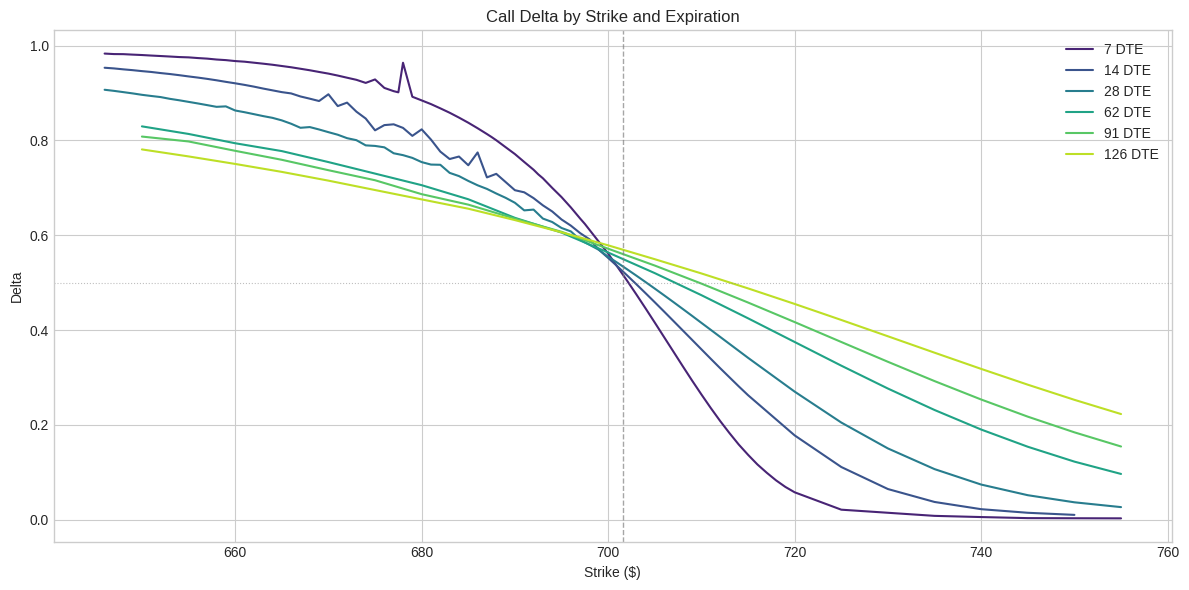

In [10]:
# Delta across strikes for each expiration (line plot)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_exps)))

for i, exp_str in enumerate(selected_exps):
    exp_data = surface[surface["expiration"] == exp_str].sort_values("strike")
    if len(exp_data) == 0:
        continue
    dte = exp_data["dte"].iloc[0]
    ax.plot(exp_data["strike"], exp_data["delta"],
            color=colors[i], linewidth=1.5, label=f"{dte} DTE")

ax.axvline(x=spot, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(y=0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Delta")
ax.set_title("Call Delta by Strike and Expiration")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Time Decay Analysis: Theta vs Days to Expiration

For ATM options, theta accelerates as expiration approaches.
Let us visualize this decay curve.

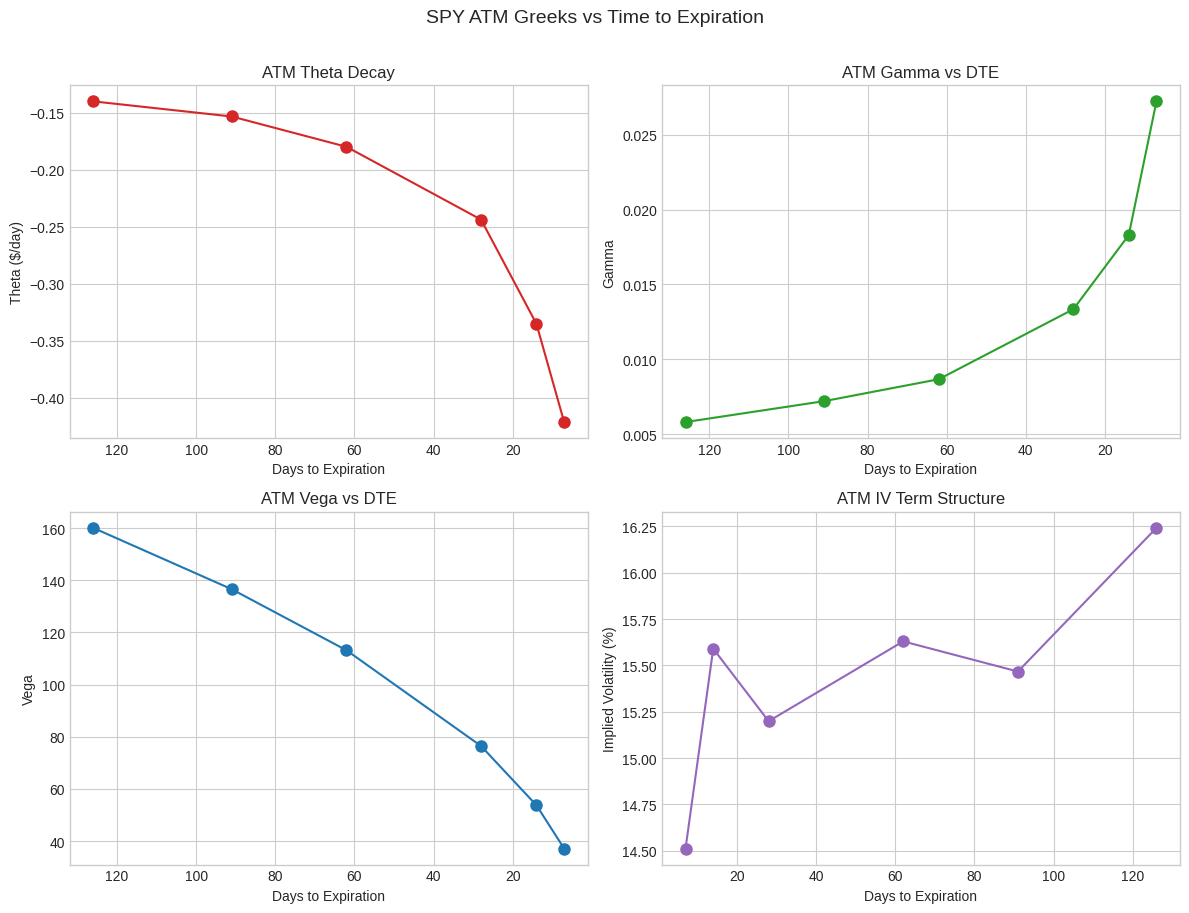

In [11]:
# Filter to near-ATM options (moneyness 0.99 - 1.01)
atm = surface[(surface["moneyness"] >= 0.99) & (surface["moneyness"] <= 1.01)].copy()
atm_avg = atm.groupby("dte").agg({
    "theta": "mean",
    "gamma": "mean",
    "vega": "mean",
    "iv": "mean",
}).reset_index().sort_values("dte")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Theta vs DTE
axes[0, 0].plot(atm_avg["dte"], atm_avg["theta"], "o-", color="#d62728", markersize=8)
axes[0, 0].set_xlabel("Days to Expiration")
axes[0, 0].set_ylabel("Theta ($/day)")
axes[0, 0].set_title("ATM Theta Decay")
axes[0, 0].invert_xaxis()

# Gamma vs DTE
axes[0, 1].plot(atm_avg["dte"], atm_avg["gamma"], "o-", color="#2ca02c", markersize=8)
axes[0, 1].set_xlabel("Days to Expiration")
axes[0, 1].set_ylabel("Gamma")
axes[0, 1].set_title("ATM Gamma vs DTE")
axes[0, 1].invert_xaxis()

# Vega vs DTE
axes[1, 0].plot(atm_avg["dte"], atm_avg["vega"], "o-", color="#1f77b4", markersize=8)
axes[1, 0].set_xlabel("Days to Expiration")
axes[1, 0].set_ylabel("Vega")
axes[1, 0].set_title("ATM Vega vs DTE")
axes[1, 0].invert_xaxis()

# IV term structure
axes[1, 1].plot(atm_avg["dte"], atm_avg["iv"] * 100, "o-", color="#9467bd", markersize=8)
axes[1, 1].set_xlabel("Days to Expiration")
axes[1, 1].set_ylabel("Implied Volatility (%)")
axes[1, 1].set_title("ATM IV Term Structure")

plt.suptitle("SPY ATM Greeks vs Time to Expiration", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

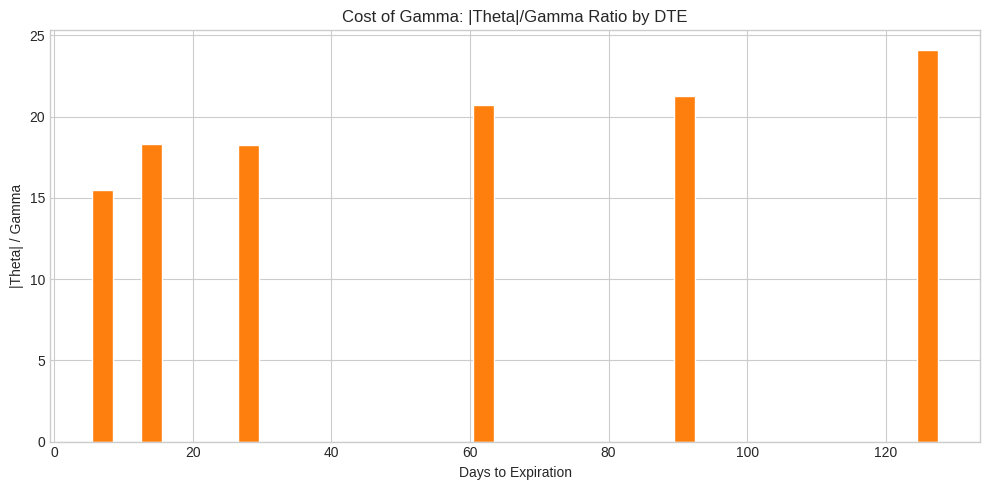

In [12]:
# Theta/Gamma ratio (measures the cost of gamma exposure)
atm_avg["theta_gamma_ratio"] = atm_avg["theta"].abs() / atm_avg["gamma"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(atm_avg["dte"], atm_avg["theta_gamma_ratio"],
       color="#ff7f0e", width=3, edgecolor="white")
ax.set_xlabel("Days to Expiration")
ax.set_ylabel("|Theta| / Gamma")
ax.set_title("Cost of Gamma: |Theta|/Gamma Ratio by DTE")

plt.tight_layout()
plt.show()

---

**Next:** [105 --- Real-Time Streaming with FPSS](105_realtime_streaming.ipynb)